# Notebook 19 — Equidad, sesgos algorítmicos y técnicas de mitigación

En este notebook estudiaremos cómo detectar y analizar posibles disparidades entre grupos en un sistema de clasificación.

Usaremos un ejemplo sintético de **scoring crediticio**. El objetivo será predecir si una solicitud será aprobada.

## Objetivos

Al finalizar el notebook deberías ser capaz de:

- distinguir desempeño global y desempeño por grupo;
- identificar disparidades en tasas de aprobación;
- calcular métricas de equidad;
- analizar matrices de confusión por grupo;
- comprender *Demographic Parity*;
- comprender *Equal Opportunity*;
- comprender *Equalized Odds*;
- detectar variables proxy;
- aplicar reponderación durante el entrenamiento;
- estudiar ajustes de umbral como técnica de postprocesamiento;
- analizar el compromiso entre desempeño y equidad;
- reconocer que ninguna métrica de equidad es universal.

> **Advertencia**
>
> Este notebook es didáctico. En aplicaciones reales, las decisiones sobre atributos protegidos, umbrales y técnicas de mitigación deben revisarse con especialistas legales, regulatorios, éticos y de negocio.

## 1. Importación de librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

pd.options.display.float_format = "{:,.4f}".format


## 2. Generación de un caso sintético de scoring crediticio

Simularemos:

- ingreso;
- antigüedad laboral;
- razón deuda-ingreso;
- historial de morosidad;
- puntaje de comportamiento;
- zona geográfica;
- grupo protegido sintético.

La variable objetivo será:

- `1`: crédito que habría resultado favorable;
- `0`: crédito que habría resultado desfavorable.

Introduciremos un sesgo histórico en la decisión observada para mostrar cómo puede propagarse.

In [2]:
n_samples = 8_000

group = rng.integers(0, 2, size=n_samples)

income = rng.lognormal(
    mean=10.8 - 0.18 * group,
    sigma=0.45,
    size=n_samples,
)

employment_years = np.clip(
    rng.normal(
        loc=7.5 - 1.2 * group,
        scale=4.0,
        size=n_samples,
    ),
    0,
    30,
)

debt_to_income = np.clip(
    rng.beta(
        a=2.2 + 0.4 * group,
        b=5.0,
        size=n_samples,
    ),
    0,
    1,
)

past_default = rng.binomial(
    1,
    p=np.clip(
        0.08
        + 0.10 * group
        + 0.18 * debt_to_income,
        0,
        0.75,
    ),
)

behavior_score = np.clip(
    rng.normal(
        loc=680 - 22 * group,
        scale=55,
        size=n_samples,
    ),
    300,
    850,
)

# Variable proxy correlacionada con el grupo
zone_proxy = rng.binomial(
    1,
    p=np.where(group == 1, 0.72, 0.28),
)

latent_score = (
    -3.0
    + 0.000035 * income
    + 0.065 * employment_years
    - 3.0 * debt_to_income
    - 1.6 * past_default
    + 0.008 * (behavior_score - 600)
)

true_probability = 1 / (
    1 + np.exp(-latent_score)
)

true_outcome = rng.binomial(
    1,
    true_probability,
)

# Decisión histórica con penalización adicional por grupo y proxy
historical_score = (
    latent_score
    - 0.45 * group
    - 0.35 * zone_proxy
    + rng.normal(0, 0.35, n_samples)
)

historical_probability = 1 / (
    1 + np.exp(-historical_score)
)

historical_approval = rng.binomial(
    1,
    historical_probability,
)

data = pd.DataFrame({
    "ingreso": income,
    "antiguedad_laboral": employment_years,
    "deuda_ingreso": debt_to_income,
    "morosidad_previa": past_default,
    "puntaje_comportamiento": behavior_score,
    "zona_proxy": zone_proxy,
    "grupo": group,
    "resultado_real": true_outcome,
    "aprobacion_historica": historical_approval,
})

data.head()


,ingreso,antiguedad_laboral,deuda_ingreso,morosidad_previa,puntaje_comportamiento,zona_proxy,grupo,resultado_real,aprobacion_historica
0,"30,691.1499",6.5379,0.2124,0,730.8754,0,0,1,0
1,"20,879.0759",5.2748,0.2508,0,648.7886,1,1,0,0
2,"75,257.2301",0.0000,0.2467,0,691.4955,1,1,1,1
3,"145,816.1055",7.2079,0.4004,0,675.0661,1,0,1,0
4,"39,573.4175",0.0000,0.3397,0,696.7407,0,0,0,0


## 3. Exploración de disparidades históricas

Primero analizaremos las tasas observadas por grupo.

In [3]:
historical_summary = (
    data
    .groupby("grupo")
    .agg(
        observaciones=("grupo", "size"),
        tasa_resultado_favorable=("resultado_real", "mean"),
        tasa_aprobacion_historica=("aprobacion_historica", "mean"),
        ingreso_promedio=("ingreso", "mean"),
        deuda_ingreso_promedio=("deuda_ingreso", "mean"),
    )
)

historical_summary


,observaciones,tasa_resultado_favorable,tasa_aprobacion_historica,ingreso_promedio,deuda_ingreso_promedio
grupo,,,,,
0,4063,0.3062,0.2919,"54,039.3338",0.3097
1,3937,0.1834,0.1204,"45,345.4714",0.3437


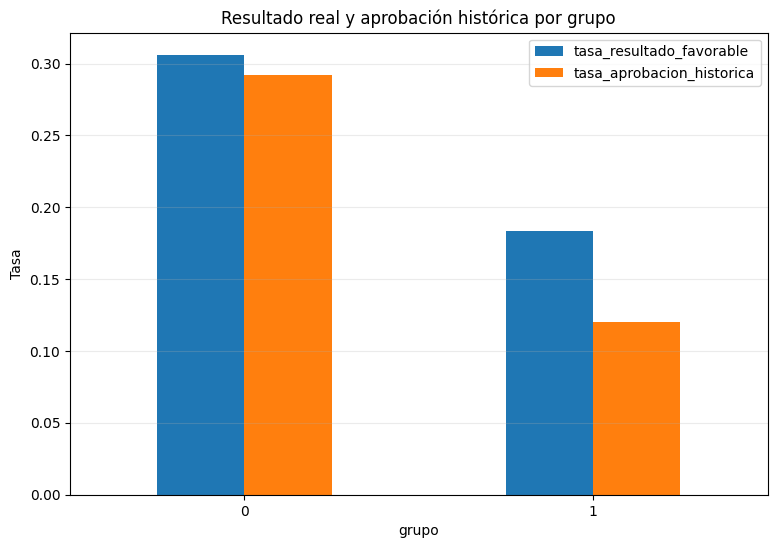

In [4]:
historical_summary[
    [
        "tasa_resultado_favorable",
        "tasa_aprobacion_historica",
    ]
].plot(
    kind="bar",
    figsize=(9, 6),
)

plt.ylabel("Tasa")
plt.title("Resultado real y aprobación histórica por grupo")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.25)
plt.show()


La diferencia entre resultado favorable y aprobación histórica puede revelar que el proceso histórico no trató a los grupos de la misma manera.

Una diferencia observada no demuestra por sí sola discriminación. Puede surgir por:

- diferencias en tasas base;
- calidad o cobertura de datos;
- variables proxy;
- reglas históricas;
- errores de medición;
- sesgo de selección.

## 4. Definición del problema de modelado

Entrenaremos un modelo para predecir `resultado_real`.

Primero incluiremos una variable proxy, pero no incluiremos directamente el grupo protegido como predictor.

In [5]:
feature_columns = [
    "ingreso",
    "antiguedad_laboral",
    "deuda_ingreso",
    "morosidad_previa",
    "puntaje_comportamiento",
    "zona_proxy",
]

X = data[feature_columns]
y = data["resultado_real"]
sensitive_attribute = data["grupo"]

(
    X_train,
    X_test,
    y_train,
    y_test,
    group_train,
    group_test,
) = train_test_split(
    X,
    y,
    sensitive_attribute,
    test_size=0.30,
    stratify=sensitive_attribute,
    random_state=RANDOM_STATE,
)

print(X_train.shape, X_test.shape)


(5600, 6) (2400, 6)


## 5. Modelo base

In [6]:
baseline_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "logistic_regression",
        LogisticRegression(
            max_iter=2_000,
            random_state=RANDOM_STATE,
        ),
    ),
])

baseline_model.fit(
    X_train,
    y_train,
)

baseline_probabilities = baseline_model.predict_proba(
    X_test
)[:, 1]

baseline_predictions = (
    baseline_probabilities >= 0.50
).astype(int)

pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
    ],
    "Valor": [
        accuracy_score(
            y_test,
            baseline_predictions,
        ),
        precision_score(
            y_test,
            baseline_predictions,
        ),
        recall_score(
            y_test,
            baseline_predictions,
        ),
        f1_score(
            y_test,
            baseline_predictions,
        ),
        roc_auc_score(
            y_test,
            baseline_probabilities,
        ),
    ],
})


,Métrica,Valor
0,Accuracy,0.8008
1,Precision,0.7121
2,Recall,0.3803
3,F1,0.4958
4,ROC-AUC,0.8017


El desempeño global puede ocultar diferencias importantes entre grupos.

## 6. Funciones auxiliares para métricas por grupo

In [7]:
def group_classification_metrics(
    y_true,
    y_pred,
    y_score,
    group_values,
):
    rows = []

    for group_value in np.sort(
        np.unique(group_values)
    ):
        mask = (
            np.asarray(group_values)
            == group_value
        )

        y_true_group = np.asarray(y_true)[mask]
        y_pred_group = np.asarray(y_pred)[mask]
        y_score_group = np.asarray(y_score)[mask]

        tn, fp, fn, tp = confusion_matrix(
            y_true_group,
            y_pred_group,
            labels=[0, 1],
        ).ravel()

        rows.append({
            "grupo": group_value,
            "n": mask.sum(),
            "tasa_seleccion": y_pred_group.mean(),
            "accuracy": accuracy_score(
                y_true_group,
                y_pred_group,
            ),
            "precision": precision_score(
                y_true_group,
                y_pred_group,
                zero_division=0,
            ),
            "recall_tpr": recall_score(
                y_true_group,
                y_pred_group,
                zero_division=0,
            ),
            "fpr": fp / (fp + tn)
            if (fp + tn) > 0
            else np.nan,
            "fnr": fn / (fn + tp)
            if (fn + tp) > 0
            else np.nan,
            "f1": f1_score(
                y_true_group,
                y_pred_group,
                zero_division=0,
            ),
            "roc_auc": roc_auc_score(
                y_true_group,
                y_score_group,
            )
            if len(np.unique(y_true_group)) == 2
            else np.nan,
        })

    return pd.DataFrame(rows)


In [8]:
baseline_group_metrics = group_classification_metrics(
    y_test,
    baseline_predictions,
    baseline_probabilities,
    group_test,
)

baseline_group_metrics


,grupo,n,tasa_seleccion,accuracy,precision,recall_tpr,fpr,fnr,f1,roc_auc
0,0,1219,0.2034,0.7769,0.7137,0.4683,0.0844,0.5317,0.5655,0.8026
1,1,1181,0.0694,0.8256,0.7073,0.2417,0.0255,0.7583,0.3602,0.7876


## 7. Métricas de equidad

### Demographic Parity

Compara las tasas de selección:

\[
P(\widehat{Y}=1\mid A=0)
\quad\text{y}\quad
P(\widehat{Y}=1\mid A=1).
\]

### Equal Opportunity

Compara los verdaderos positivos:

\[
P(\widehat{Y}=1\mid Y=1,A=0)
\quad\text{y}\quad
P(\widehat{Y}=1\mid Y=1,A=1).
\]

### Equalized Odds

Requiere igualdad aproximada en:

- TPR;
- FPR.

Estas métricas pueden ser incompatibles cuando las tasas base difieren.

In [9]:
def fairness_summary(group_metrics):
    group_0 = group_metrics.loc[
        group_metrics["grupo"] == 0
    ].iloc[0]

    group_1 = group_metrics.loc[
        group_metrics["grupo"] == 1
    ].iloc[0]

    selection_rate_ratio = (
        group_1["tasa_seleccion"]
        / group_0["tasa_seleccion"]
    )

    return pd.DataFrame({
        "Métrica": [
            "Diferencia en tasa de selección",
            "Razón de tasas de selección",
            "Diferencia de TPR",
            "Diferencia de FPR",
            "Diferencia de accuracy",
        ],
        "Valor": [
            group_1["tasa_seleccion"]
            - group_0["tasa_seleccion"],
            selection_rate_ratio,
            group_1["recall_tpr"]
            - group_0["recall_tpr"],
            group_1["fpr"]
            - group_0["fpr"],
            group_1["accuracy"]
            - group_0["accuracy"],
        ],
    })


baseline_fairness = fairness_summary(
    baseline_group_metrics
)

baseline_fairness


,Métrica,Valor
0,Diferencia en tasa de selección,-0.1340
1,Razón de tasas de selección,0.3413
2,Diferencia de TPR,-0.2266
3,Diferencia de FPR,-0.0589
4,Diferencia de accuracy,0.0487


Una razón de tasas de selección cercana a 1 indica mayor similitud, pero no demuestra por sí sola que el sistema sea justo.

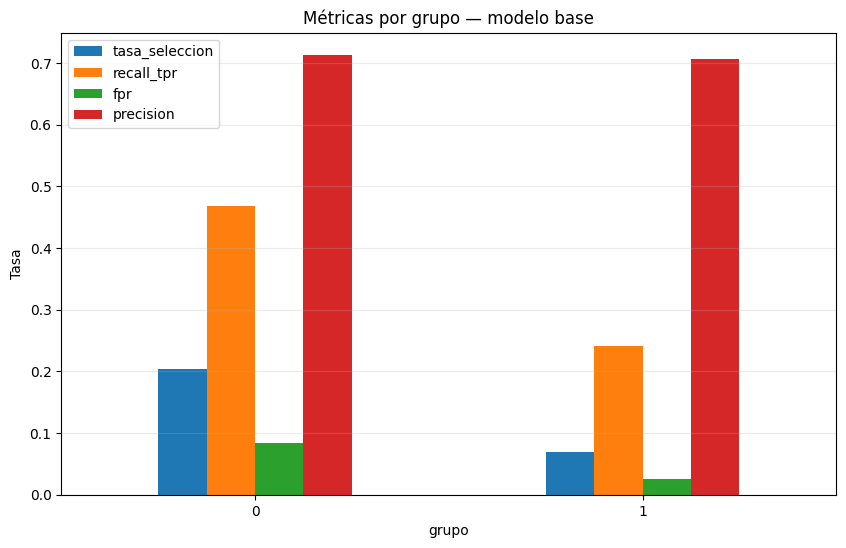

In [10]:
baseline_group_metrics.set_index("grupo")[
    [
        "tasa_seleccion",
        "recall_tpr",
        "fpr",
        "precision",
    ]
].plot(
    kind="bar",
    figsize=(10, 6),
)

plt.ylabel("Tasa")
plt.title("Métricas por grupo — modelo base")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.25)
plt.show()


## 8. Matrices de confusión por grupo

In [11]:
for group_value in [0, 1]:
    mask = np.asarray(group_test) == group_value

    matrix = confusion_matrix(
        np.asarray(y_test)[mask],
        baseline_predictions[mask],
        labels=[0, 1],
    )

    print(f"Grupo {group_value}")
    display(
        pd.DataFrame(
            matrix,
            index=["Real 0", "Real 1"],
            columns=["Predicho 0", "Predicho 1"],
        )
    )


Grupo 0


,Predicho 0,Predicho 1
Real 0,770,71
Real 1,201,177


Grupo 1


,Predicho 0,Predicho 1
Real 0,917,24
Real 1,182,58


## 9. Variable proxy

Eliminar el atributo protegido no garantiza equidad.

Una variable puede actuar como proxy cuando está correlacionada con el grupo y transmite información similar.

In [12]:
proxy_summary = pd.crosstab(
    data["grupo"],
    data["zona_proxy"],
    normalize="index",
)

proxy_summary


zona_proxy,0,1
grupo,,
0,0.7248,0.2752
1,0.2827,0.7173


## 10. Modelo sin la variable proxy

Compararemos el modelo base con otro que excluye `zona_proxy`.

In [13]:
features_without_proxy = [
    column
    for column in feature_columns
    if column != "zona_proxy"
]

model_without_proxy = Pipeline([
    ("scaler", StandardScaler()),
    (
        "logistic_regression",
        LogisticRegression(
            max_iter=2_000,
            random_state=RANDOM_STATE,
        ),
    ),
])

model_without_proxy.fit(
    X_train[features_without_proxy],
    y_train,
)

probabilities_without_proxy = (
    model_without_proxy
    .predict_proba(
        X_test[features_without_proxy]
    )[:, 1]
)

predictions_without_proxy = (
    probabilities_without_proxy >= 0.50
).astype(int)

group_metrics_without_proxy = group_classification_metrics(
    y_test,
    predictions_without_proxy,
    probabilities_without_proxy,
    group_test,
)

group_metrics_without_proxy


,grupo,n,tasa_seleccion,accuracy,precision,recall_tpr,fpr,fnr,f1,roc_auc
0,0,1219,0.1977,0.7744,0.7137,0.4550,0.0820,0.5450,0.5557,0.8019
1,1,1181,0.0711,0.8290,0.7262,0.2542,0.0244,0.7458,0.3765,0.7885


In [14]:
comparison_proxy = pd.DataFrame({
    "Modelo": [
        "Con proxy",
        "Sin proxy",
    ],
    "Accuracy": [
        accuracy_score(
            y_test,
            baseline_predictions,
        ),
        accuracy_score(
            y_test,
            predictions_without_proxy,
        ),
    ],
    "ROC-AUC": [
        roc_auc_score(
            y_test,
            baseline_probabilities,
        ),
        roc_auc_score(
            y_test,
            probabilities_without_proxy,
        ),
    ],
    "Diferencia selección": [
        fairness_summary(
            baseline_group_metrics
        ).iloc[0]["Valor"],
        fairness_summary(
            group_metrics_without_proxy
        ).iloc[0]["Valor"],
    ],
    "Diferencia TPR": [
        fairness_summary(
            baseline_group_metrics
        ).iloc[2]["Valor"],
        fairness_summary(
            group_metrics_without_proxy
        ).iloc[2]["Valor"],
    ],
})

comparison_proxy


,Modelo,Accuracy,ROC-AUC,Diferencia selección,Diferencia TPR
0,Con proxy,0.8008,0.8017,-0.1340,-0.2266
1,Sin proxy,0.8013,0.8019,-0.1266,-0.2009


Eliminar una proxy puede reducir disparidades, pero no siempre las elimina porque otras variables pueden conservar correlaciones similares.

## 11. Mitigación mediante reponderación

La reponderación asigna pesos distintos a combinaciones de grupo y etiqueta.

El objetivo es reducir la dependencia entre:

- grupo protegido;
- variable objetivo observada.

Esta es una técnica de preprocesamiento/entrenamiento.

In [15]:
def compute_reweighing_weights(
    y_values,
    group_values,
):
    frame = pd.DataFrame({
        "y": np.asarray(y_values),
        "group": np.asarray(group_values),
    })

    n = len(frame)

    probability_y = (
        frame["y"]
        .value_counts(normalize=True)
    )

    probability_group = (
        frame["group"]
        .value_counts(normalize=True)
    )

    probability_joint = (
        frame
        .value_counts(
            ["group", "y"],
            normalize=True,
        )
    )

    weights = np.empty(n)

    for index, row in frame.iterrows():
        weights[index] = (
            probability_group[row["group"]]
            * probability_y[row["y"]]
            / probability_joint.loc[
                (row["group"], row["y"])
            ]
        )

    return weights


reweighing_weights = compute_reweighing_weights(
    y_train,
    group_train,
)

pd.Series(
    reweighing_weights
).describe()


count   5,600.0000
mean        1.0000
std         0.1566
min         0.7905
25%         0.9202
50%         0.9202
75%         1.0917
max         1.3764
dtype: float64

In [16]:
weighted_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "logistic_regression",
        LogisticRegression(
            max_iter=2_000,
            random_state=RANDOM_STATE,
        ),
    ),
])

weighted_model.fit(
    X_train,
    y_train,
    logistic_regression__sample_weight=(
        reweighing_weights
    ),
)

weighted_probabilities = weighted_model.predict_proba(
    X_test
)[:, 1]

weighted_predictions = (
    weighted_probabilities >= 0.50
).astype(int)

weighted_group_metrics = group_classification_metrics(
    y_test,
    weighted_predictions,
    weighted_probabilities,
    group_test,
)

weighted_group_metrics


,grupo,n,tasa_seleccion,accuracy,precision,recall_tpr,fpr,fnr,f1,roc_auc
0,0,1219,0.1805,0.7752,0.7364,0.4286,0.0690,0.5714,0.5418,0.7998
1,1,1181,0.0694,0.8256,0.7073,0.2417,0.0255,0.7583,0.3602,0.7884


In [17]:
weighted_fairness = fairness_summary(
    weighted_group_metrics
)

weighted_fairness


,Métrica,Valor
0,Diferencia en tasa de selección,-0.1110
1,Razón de tasas de selección,0.3847
2,Diferencia de TPR,-0.1869
3,Diferencia de FPR,-0.0435
4,Diferencia de accuracy,0.0503


## 12. Comparación antes y después de reponderar

In [18]:
model_comparison = pd.DataFrame({
    "Modelo": [
        "Base",
        "Reponderado",
    ],
    "Accuracy": [
        accuracy_score(
            y_test,
            baseline_predictions,
        ),
        accuracy_score(
            y_test,
            weighted_predictions,
        ),
    ],
    "F1": [
        f1_score(
            y_test,
            baseline_predictions,
        ),
        f1_score(
            y_test,
            weighted_predictions,
        ),
    ],
    "ROC-AUC": [
        roc_auc_score(
            y_test,
            baseline_probabilities,
        ),
        roc_auc_score(
            y_test,
            weighted_probabilities,
        ),
    ],
    "Diferencia selección": [
        baseline_fairness.iloc[0]["Valor"],
        weighted_fairness.iloc[0]["Valor"],
    ],
    "Diferencia TPR": [
        baseline_fairness.iloc[2]["Valor"],
        weighted_fairness.iloc[2]["Valor"],
    ],
    "Diferencia FPR": [
        baseline_fairness.iloc[3]["Valor"],
        weighted_fairness.iloc[3]["Valor"],
    ],
})

model_comparison


,Modelo,Accuracy,F1,ROC-AUC,Diferencia selección,Diferencia TPR,Diferencia FPR
0,Base,0.8008,0.4958,0.8017,-0.1340,-0.2266,-0.0589
1,Reponderado,0.8000,0.4783,0.8009,-0.1110,-0.1869,-0.0435


La mitigación puede mejorar una métrica de equidad y empeorar otra. También puede modificar el desempeño global.

## 13. Postprocesamiento mediante umbrales

Otra posibilidad es modificar el umbral de decisión.

A continuación buscaremos, con fines didácticos, un umbral para el grupo 1 que aproxime el TPR del grupo 0.

> **Advertencia**
>
> El uso de umbrales distintos por grupo puede estar restringido o prohibido en ciertos contextos. Debe revisarse jurídicamente antes de implementarse.

In [19]:
baseline_target_tpr = (
    baseline_group_metrics
    .loc[
        baseline_group_metrics["grupo"] == 0,
        "recall_tpr",
    ]
    .iloc[0]
)

threshold_candidates = np.linspace(
    0.05,
    0.95,
    181,
)

threshold_search_rows = []

group_test_array = np.asarray(group_test)
y_test_array = np.asarray(y_test)

for threshold_group_1 in threshold_candidates:
    adjusted_predictions = (
        baseline_probabilities >= 0.50
    ).astype(int)

    group_1_mask = (
        group_test_array == 1
    )

    adjusted_predictions[group_1_mask] = (
        baseline_probabilities[group_1_mask]
        >= threshold_group_1
    ).astype(int)

    metrics = group_classification_metrics(
        y_test_array,
        adjusted_predictions,
        baseline_probabilities,
        group_test_array,
    )

    tpr_group_1 = (
        metrics
        .loc[
            metrics["grupo"] == 1,
            "recall_tpr",
        ]
        .iloc[0]
    )

    threshold_search_rows.append({
        "threshold_group_1": threshold_group_1,
        "tpr_group_1": tpr_group_1,
        "distance_to_target": abs(
            tpr_group_1
            - baseline_target_tpr
        ),
    })

threshold_search = pd.DataFrame(
    threshold_search_rows
)

best_threshold_group_1 = (
    threshold_search
    .sort_values("distance_to_target")
    .iloc[0]["threshold_group_1"]
)

best_threshold_group_1


np.float64(0.295)

In [20]:
adjusted_predictions = (
    baseline_probabilities >= 0.50
).astype(int)

group_1_mask = (
    group_test_array == 1
)

adjusted_predictions[group_1_mask] = (
    baseline_probabilities[group_1_mask]
    >= best_threshold_group_1
).astype(int)

adjusted_group_metrics = group_classification_metrics(
    y_test_array,
    adjusted_predictions,
    baseline_probabilities,
    group_test_array,
)

adjusted_group_metrics


,grupo,n,tasa_seleccion,accuracy,precision,recall_tpr,fpr,fnr,f1,roc_auc
0,0,1219,0.2034,0.7769,0.7137,0.4683,0.0844,0.5317,0.5655,0.8026
1,1,1181,0.1888,0.7993,0.5067,0.4708,0.1169,0.5292,0.4881,0.7876


In [21]:
adjusted_fairness = fairness_summary(
    adjusted_group_metrics
)

adjusted_fairness


,Métrica,Valor
0,Diferencia en tasa de selección,-0.0146
1,Razón de tasas de selección,0.9281
2,Diferencia de TPR,0.0026
3,Diferencia de FPR,0.0325
4,Diferencia de accuracy,0.0225


## 14. Frontera entre desempeño y equidad

No existe una única solución óptima.

Las decisiones deben considerar:

- tipo de daño;
- costo de falsos positivos;
- costo de falsos negativos;
- tasas base;
- población afectada;
- regulación;
- capacidad de apelación;
- impacto acumulado.

In [22]:
final_comparison = pd.DataFrame({
    "Modelo": [
        "Base",
        "Sin proxy",
        "Reponderado",
        "Umbral ajustado",
    ],
    "Accuracy": [
        accuracy_score(
            y_test,
            baseline_predictions,
        ),
        accuracy_score(
            y_test,
            predictions_without_proxy,
        ),
        accuracy_score(
            y_test,
            weighted_predictions,
        ),
        accuracy_score(
            y_test,
            adjusted_predictions,
        ),
    ],
    "F1": [
        f1_score(
            y_test,
            baseline_predictions,
        ),
        f1_score(
            y_test,
            predictions_without_proxy,
        ),
        f1_score(
            y_test,
            weighted_predictions,
        ),
        f1_score(
            y_test,
            adjusted_predictions,
        ),
    ],
    "Diferencia selección": [
        baseline_fairness.iloc[0]["Valor"],
        fairness_summary(
            group_metrics_without_proxy
        ).iloc[0]["Valor"],
        weighted_fairness.iloc[0]["Valor"],
        adjusted_fairness.iloc[0]["Valor"],
    ],
    "Diferencia TPR": [
        baseline_fairness.iloc[2]["Valor"],
        fairness_summary(
            group_metrics_without_proxy
        ).iloc[2]["Valor"],
        weighted_fairness.iloc[2]["Valor"],
        adjusted_fairness.iloc[2]["Valor"],
    ],
    "Diferencia FPR": [
        baseline_fairness.iloc[3]["Valor"],
        fairness_summary(
            group_metrics_without_proxy
        ).iloc[3]["Valor"],
        weighted_fairness.iloc[3]["Valor"],
        adjusted_fairness.iloc[3]["Valor"],
    ],
})

final_comparison


,Modelo,Accuracy,F1,Diferencia selección,Diferencia TPR,Diferencia FPR
0,Base,0.8008,0.4958,-0.1340,-0.2266,-0.0589
1,Sin proxy,0.8013,0.4942,-0.1266,-0.2009,-0.0576
2,Reponderado,0.8000,0.4783,-0.1110,-0.1869,-0.0435
3,Umbral ajustado,0.7879,0.5326,-0.0146,0.0026,0.0325


## 15. Auditoría por subgrupos

La evaluación no debería limitarse a un solo atributo.

En problemas reales conviene revisar:

- intersecciones entre grupos;
- regiones;
- rangos de edad;
- niveles de ingreso;
- cohortes temporales;
- productos;
- canales.

Un modelo puede parecer equitativo en promedio y presentar disparidades dentro de subgrupos.

## 16. Fuentes comunes de sesgo

### Sesgo histórico

Las etiquetas reflejan decisiones pasadas.

### Sesgo de representación

Algunos grupos aparecen poco en los datos.

### Sesgo de medición

Las variables miden peor el fenómeno para ciertos grupos.

### Sesgo de selección

La muestra observada no representa a la población objetivo.

### Variables proxy

Variables aparentemente neutrales reproducen información protegida.

### Sesgo de despliegue

El modelo se utiliza fuera del contexto para el que fue diseñado.

## 17. Buenas prácticas

1. Definir el daño que se desea evitar.
2. Elegir métricas de equidad coherentes con ese daño.
3. Reportar métricas globales y por grupo.
4. Auditar variables proxy.
5. Documentar los datos y decisiones.
6. Evaluar intersecciones entre grupos.
7. Incorporar revisión humana y mecanismos de apelación.
8. Monitorear cambios después del despliegue.
9. Revisar impactos, no solo métricas.
10. Involucrar a expertos legales y a poblaciones afectadas.

## 18. Errores frecuentes

1. Eliminar la variable protegida y asumir que el problema quedó resuelto.
2. Evaluar solo accuracy global.
3. Elegir una métrica de equidad sin considerar el daño.
4. Interpretar cualquier diferencia como prueba automática de discriminación.
5. Aplicar umbrales por grupo sin revisión legal.
6. Optimizar una métrica y ocultar deterioros en otras.
7. Ignorar tasas base.
8. No revisar proxies.
9. Auditar una sola vez.
10. Confundir equidad matemática con justicia social completa.

## 19. Experimentos sugeridos

1. Aumenta la correlación entre `zona_proxy` y `grupo`.
2. Elimina varias variables correlacionadas con el grupo.
3. Cambia el umbral global.
4. Optimiza Demographic Parity.
5. Optimiza Equal Opportunity.
6. Compara resultados cuando las tasas base son iguales.
7. Reduce la representación de un grupo en entrenamiento.
8. Introduce errores de medición distintos por grupo.
9. Evalúa intersecciones entre grupo y nivel de ingreso.
10. Simula monitoreo temporal después del despliegue.

## 20. Resumen

En este notebook:

- construimos un caso sintético de scoring crediticio;
- analizamos disparidades históricas;
- entrenamos un modelo base;
- calculamos métricas por grupo;
- estudiamos Demographic Parity;
- estudiamos Equal Opportunity y Equalized Odds;
- analizamos una variable proxy;
- aplicamos reponderación;
- exploramos ajuste de umbrales;
- comparamos desempeño y equidad;
- discutimos fuentes de sesgo y buenas prácticas.

La equidad algorítmica no se resuelve con una sola métrica ni con una sola técnica. Requiere definir el daño relevante, comprender el contexto y evaluar continuamente los impactos del sistema.